In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

In [3]:
df = pd.read_csv("EMS_Feature_Engineered.csv")

print(df.shape)

df.head()

(887919, 25)


,initial_call_type,final_call_type,dispatch_response_seconds_qy,incident_response_seconds_qy,incident_travel_tm_seconds_qy,zipcode,borough,incident_dispatch_area,hour,month,...,peak_hour,night_shift,travel_duration,hospital_time,closure_time,zipcode_frequency,borough_frequency,dispatch_area_frequency,initial_call_frequency,final_call_frequency
0,53.0,51.0,53.0,393.0,340.0,11365.0,3.0,26.0,0.0,1.0,...,0.0,1.0,323.0,8279834.0,-8276829.0,9311.0,743558.0,43405.0,437223.0,416373.0
1,21.0,17.0,84.0,430.0,346.0,10457.0,0.0,1.0,0.0,1.0,...,0.0,1.0,330.0,1123.0,3195.0,59102.0,854212.0,253459.0,188550.0,197297.0
2,99.0,111.0,0.0,564.0,433.0,11224.0,1.0,6.0,0.0,1.0,...,0.0,1.0,433.0,7323.0,6840.0,34013.0,1002290.0,150556.0,985.0,8795.0
3,84.0,95.0,1485.0,1934.0,449.0,10033.0,2.0,21.0,0.0,1.0,...,0.0,1.0,439.0,1062.0,2783.0,25033.0,873477.0,98891.0,33155.0,27167.0
4,20.0,16.0,39.0,1315.0,1276.0,11208.0,1.0,9.0,0.0,1.0,...,0.0,1.0,1253.0,3873.0,4144.0,51519.0,1002290.0,252294.0,3778.0,3513.0


In [11]:
print(df["Weekend"].dtype)

object


In [12]:
df["Weekend"] = df["Weekend"].replace({
    "True": 1,
    "False": 0
}).astype(int)

In [13]:
df = df.dropna(subset=["incident_response_seconds_qy"])

df["delay"] = (
    df["incident_response_seconds_qy"] > 480
).astype(int)

df["delay"].value_counts()

,count
delay,
1,518198
0,369720


In [14]:
features = [

    "initial_call_type",

    "zipcode",

    "borough",

    "incident_dispatch_area",

    "hour",

    "month",

    "weekday",

    "Weekend",

    "Year",

    "dispatch_delay",

    "peak_hour",

    "night_shift",

    "zipcode_frequency",

    "borough_frequency",

    "dispatch_area_frequency",

    "initial_call_frequency"

]

In [15]:
target = "delay"

In [16]:
X = df[features]

y = df[target]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [18]:
models = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=1000

        ),

    "Decision Tree":

        DecisionTreeClassifier(

            max_depth=15,

            random_state=42

        ),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=100,

            max_depth=15,

            random_state=42,

            n_jobs=-1

        ),

    "XGBoost":

        XGBClassifier(

            n_estimators=300,

            learning_rate=0.05,

            max_depth=8,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric="logloss",

            random_state=42

        ),

    "CatBoost":

        CatBoostClassifier(

            iterations=300,

            learning_rate=0.05,

            depth=8,

            verbose=0,

            random_seed=42

        )

}

In [19]:
results = []

trained_models = {}

for name, model in models.items():

    print("="*60)

    print(name)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)

    pre = precision_score(y_test, pred)

    rec = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    auc = roc_auc_score(y_test, prob)

    results.append([

        name,

        acc,

        pre,

        rec,

        f1,

        auc

    ])

    trained_models[name] = model

    print("Accuracy :", round(acc,4))

    print("Precision:", round(pre,4))

    print("Recall   :", round(rec,4))

    print("F1 Score :", round(f1,4))

    print("ROC AUC  :", round(auc,4))

Logistic Regression
Accuracy : 0.6453
Precision: 0.7115
Recall   : 0.6599
F1 Score : 0.6847
ROC AUC  : 0.7118
Decision Tree
Accuracy : 0.6994
Precision: 0.741
Recall   : 0.7454
F1 Score : 0.7432
ROC AUC  : 0.7663
Random Forest
Accuracy : 0.7127
Precision: 0.7527
Recall   : 0.7562
F1 Score : 0.7545
ROC AUC  : 0.791
XGBoost
Accuracy : 0.7228
Precision: 0.7608
Recall   : 0.7657
F1 Score : 0.7633
ROC AUC  : 0.8035
CatBoost
Accuracy : 0.7201
Precision: 0.757
Recall   : 0.7664
F1 Score : 0.7616
ROC AUC  : 0.7992


In [20]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ]

)

results_df.sort_values(

    by="F1 Score",

    ascending=False,

    inplace=True

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.722790,0.760849,0.765679,0.763256,0.803509
4,CatBoost,0.720054,0.756972,0.766364,0.761639,0.799166
2,Random Forest,0.712733,0.752713,0.756214,0.754459,0.791014
1,Decision Tree,0.699393,0.741034,0.745417,0.743219,0.766324
0,Logistic Regression,0.645323,0.711483,0.659851,0.684695,0.711761


In [21]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : XGBoost


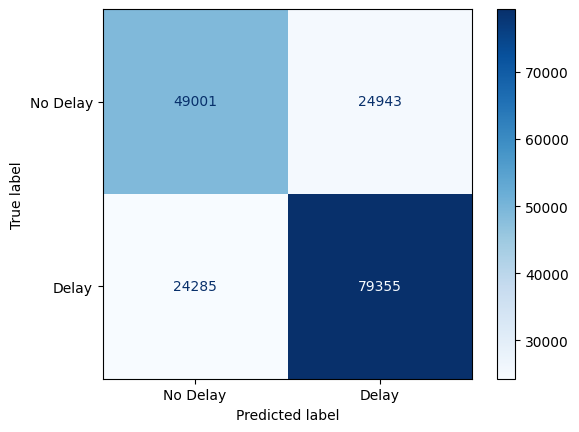

In [22]:
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No Delay","Delay"]

)

disp.plot(cmap="Blues")

plt.show()

In [23]:
print(

    classification_report(

        y_test,

        pred

    )

)

              precision    recall  f1-score   support

           0       0.67      0.66      0.67     73944
           1       0.76      0.77      0.76    103640

    accuracy                           0.72    177584
   macro avg       0.71      0.71      0.71    177584
weighted avg       0.72      0.72      0.72    177584



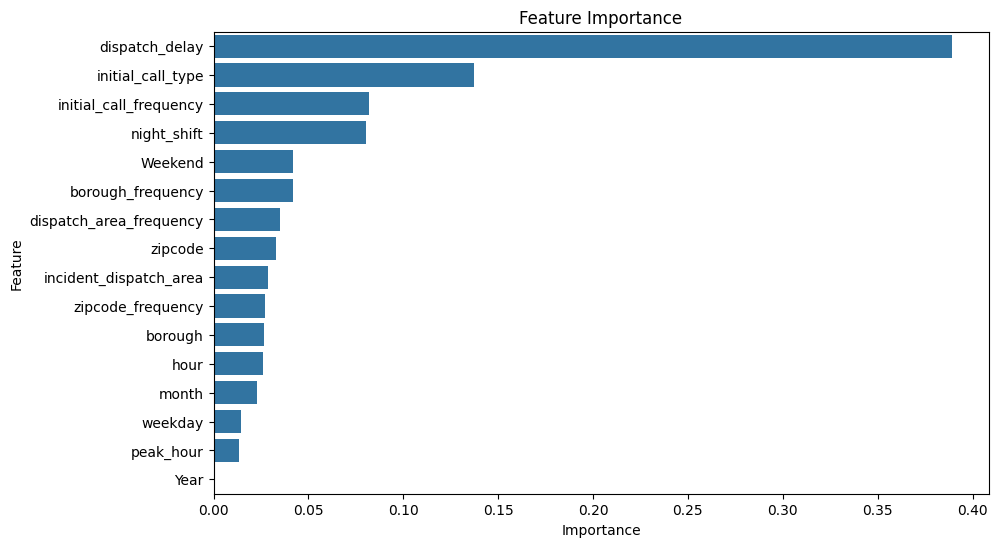

In [24]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X.columns,

        "Importance":best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    plt.figure(figsize=(10,6))

    sns.barplot(

        data=importance,

        x="Importance",

        y="Feature"

    )

    plt.title("Feature Importance")

    plt.show()

else:

    print("Feature Importance Not Available")

In [25]:
sample = X_test.iloc[:10]

prediction = best_model.predict(sample)

comparison = pd.DataFrame({

    "Actual":y_test.iloc[:10].values,

    "Predicted":prediction

})

comparison

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,0,1
4,1,0
5,1,1
6,1,0
7,0,0
8,1,0
9,0,0


In [26]:
joblib.dump(best_model, "delay_classifier.pkl")

from google.colab import files
files.download("delay_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>